## Super Bowl Insights: Viewership, Game Outcomes & Halftime Shows
### Project Overview

The Super Bowl is more than a football game; it is a major entertainment and advertising event that attracts millions of viewers each year. Beyond the game itself, the event generates significant interest through television viewership, advertising, and high-profile halftime performances. In this project, I analyze historical Super Bowl data to uncover patterns in audience size, game outcomes, and halftime entertainment.

The analysis uses three datasets containing information from 52 Super Bowls through 2018: `super_bowls.csv`, `tv.csv`, and `halftime_musicians.csv`. The `super_bowls` dataset contains game-level information such as the date, participating teams, and point difference between the winning and losing teams. The `tv` dataset contains television viewership and advertising-related information, including average U.S. viewers. The `halftime_musicians` dataset records the musicians or musical groups who performed during each halftime show and the number of songs they performed.

### Methodology

To analyze these datasets together, I first merged the three DataFrames using the `super_bowl` identifier. This created a combined dataset that links each Super Bowl to its game results, television viewership, and halftime performers.

I then used a combination of data visualization and numerical analysis to answer three main questions:

1. **TV viewership over time:** I created a line chart showing average U.S. Super Bowl viewership by date to determine whether viewership increased over time. The resulting trend was then used to assign a Boolean value to `viewership_increased`.

2. **Large-margin victories:** I created a histogram of Super Bowl point differences to examine the distribution of game margins. I then used a Boolean condition and `.sum()` to count the number of games where the winning team scored more than 40 points above the losing team, storing the result in `difference`.

3. **Most songs performed:** I grouped the combined data by halftime musician or group and summed the number of songs performed. I then sorted the results in descending order to identify the performer with the highest total number of songs, storing the result in `most_songs`.

This approach combines **data preparation, aggregation, visualization, and descriptive analysis** to turn the raw Super Bowl datasets into clear insights about viewership, game competitiveness, and halftime performances.


In [25]:
# Import libraries
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [26]:
# Load the CSV data into DataFrames
super_bowls = pd.read_csv("datasets/super_bowls.csv")
super_bowls['date'] = pd.to_datetime(super_bowls['date'])
super_bowls.head()

,date,super_bowl,venue,city,state,attendance,team_winner,winning_pts,qb_winner_1,qb_winner_2,coach_winner,team_loser,losing_pts,qb_loser_1,qb_loser_2,coach_loser,combined_pts,difference_pts
0,2018-02-04,52,U.S. Bank Stadium,Minneapolis,Minnesota,67612,Philadelphia Eagles,41,Nick Foles,NaN,Doug Pederson,New England Patriots,33,Tom Brady,NaN,Bill Belichick,74,8
1,2017-02-05,51,NRG Stadium,Houston,Texas,70807,New England Patriots,34,Tom Brady,NaN,Bill Belichick,Atlanta Falcons,28,Matt Ryan,NaN,Dan Quinn,62,6
2,2016-02-07,50,Levi's Stadium,Santa Clara,California,71088,Denver Broncos,24,Peyton Manning,NaN,Gary Kubiak,Carolina Panthers,10,Cam Newton,NaN,Ron Rivera,34,14
3,2015-02-01,49,University of Phoenix Stadium,Glendale,Arizona,70288,New England Patriots,28,Tom Brady,NaN,Bill Belichick,Seattle Seahawks,24,Russell Wilson,NaN,Pete Carroll,52,4
4,2014-02-02,48,MetLife Stadium,East Rutherford,New Jersey,82529,Seattle Seahawks,43,Russell Wilson,NaN,Pete Carroll,Denver Broncos,8,Peyton Manning,NaN,John Fox,51,35


In [27]:
tv = pd.read_csv("datasets/tv.csv")
tv.head()

,super_bowl,network,avg_us_viewers,total_us_viewers,rating_household,share_household,rating_18_49,share_18_49,ad_cost
0,52,NBC,103390000,NaN,43.1,68,33.4,78.0,5000000
1,51,Fox,111319000,172000000.0,45.3,73,37.1,79.0,5000000
2,50,CBS,111864000,167000000.0,46.6,72,37.7,79.0,5000000
3,49,NBC,114442000,168000000.0,47.5,71,39.1,79.0,4500000
4,48,Fox,112191000,167000000.0,46.7,69,39.3,77.0,4000000


In [28]:
halftime_musicians = pd.read_csv("datasets/halftime_musicians.csv")
halftime_musicians.head()

,super_bowl,musician,num_songs
0,52,Justin Timberlake,11.0
1,52,University of Minnesota Marching Band,1.0
2,51,Lady Gaga,7.0
3,50,Coldplay,6.0
4,50,Beyoncé,3.0


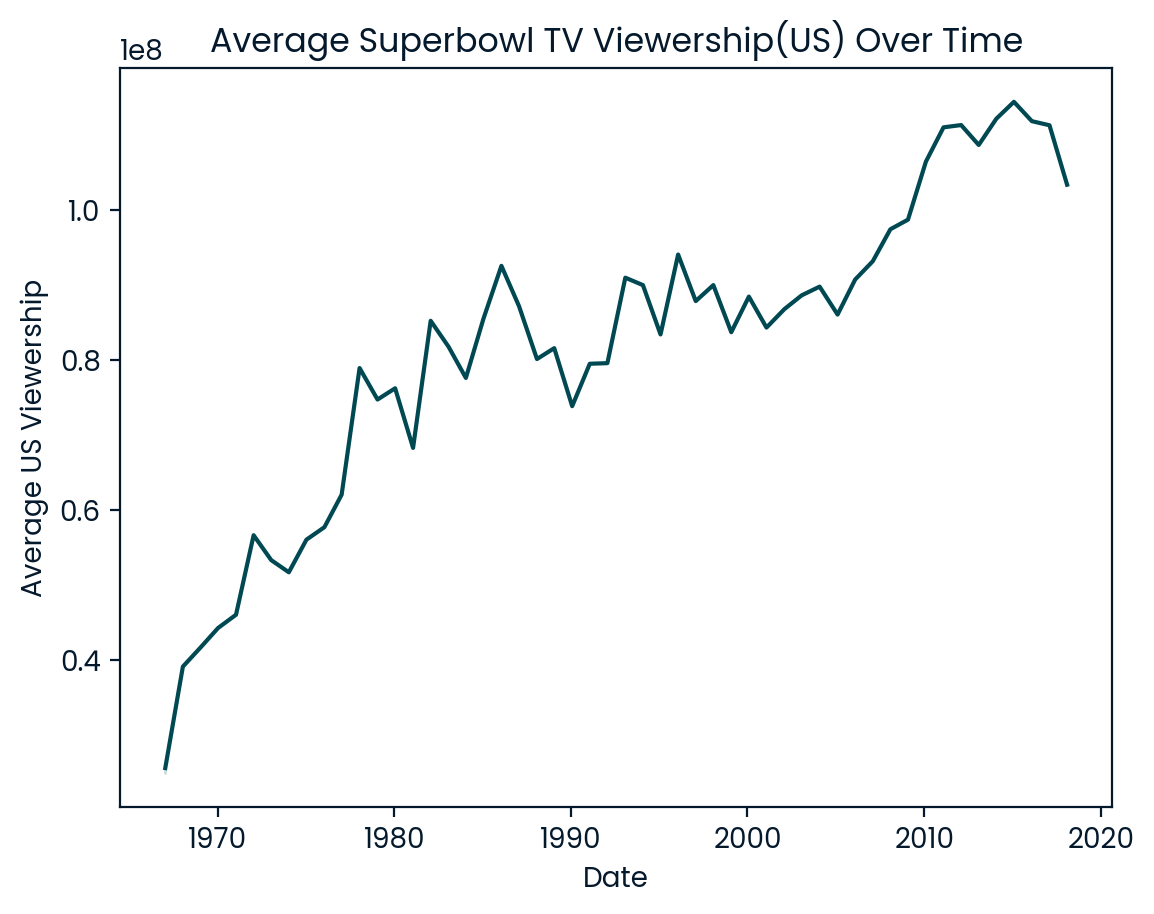

In [29]:
# 1. Has TV viewership increased over time?

# Merge all three dataframes
bowls = (super_bowls
.merge(
    tv,
    on = 'super_bowl',
    how = 'left')
.merge(
    halftime_musicians,
    on = 'super_bowl',
    how = 'left')
        )

# Create a lineplot
sns.lineplot(
    data = bowls, 
    x = 'date', 
    y = 'avg_us_viewers',
    color = '#004953'
)

plt.title('Average Superbowl TV Viewership(US) Over Time')
plt.xlabel('Date')
plt.ylabel('Average US Viewership')
plt.show()

In [30]:
# Assign answer to viewership_increased
viewership_increased = True

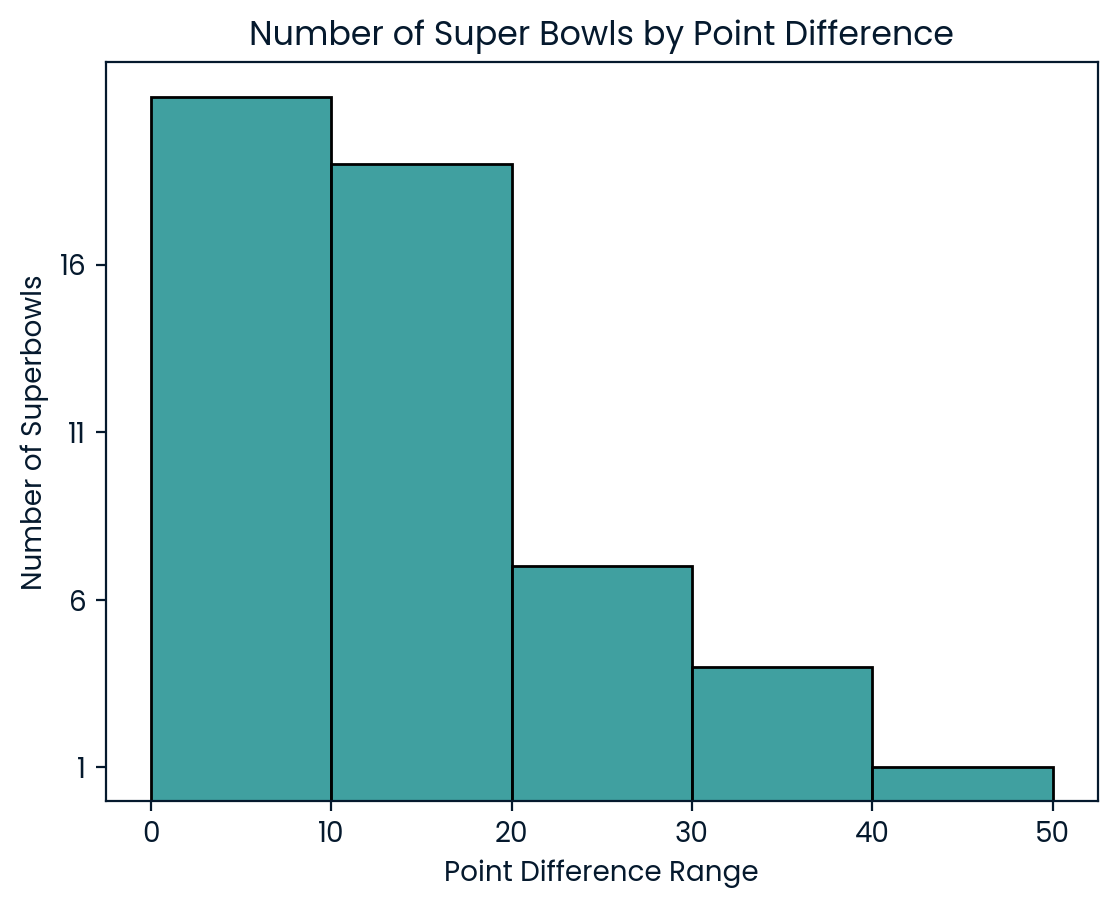

In [31]:
# 2. How many matches ended with a point difference exceeding 40?

# Create a histogram
sns.histplot(
    super_bowls, 
    x = 'difference_pts', 
    bins=[0, 10, 20, 30, 40, 50],
    color = '#008080')

plt.yticks(range(1,20,5))
plt.title('Number of Super Bowls by Point Difference')
plt.xlabel('Point Difference Range')
plt.ylabel('Number of Superbowls')
plt.show()

In [32]:
# Confirm the histogram result: only one Super Bowl had a point difference greater than 40
difference = int((super_bowls['difference_pts']>40).sum())
difference

1

In [33]:
# 3. Which artist/group performed the most songs in Super Bowl halftime shows?
songs = bowls.groupby('musician')['num_songs'].sum().sort_values(ascending=False)
songs.head(5)

musician
Justin Timberlake                                 12.0
Beyoncé                                           10.0
Diana Ross                                        10.0
Grambling State University Tiger Marching Band     9.0
Bruno Mars                                         9.0
Name: num_songs, dtype: float64

In [34]:
# Assign the artist to most_songs
most_songs = songs.index[0]
most_songs

'Justin Timberlake'